# Oxford-IIIT Pet Dataset - Semantic Segmentation

### [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Omkar M. Parkhi, Andrea Vedaldi, Andrew Zisserman, C. V. Jawahar, https://www.robots.ox.ac.uk/~vgg/data/pets/

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy matplotlib

## Import Libraries

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
%matplotlib inline

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
IMAGE_SIZE = 128
IMAGE_SIZE

128

In [6]:
NUM_CLASSES = 3
NUM_CLASSES

3

In [7]:
BASE_CHANNELS = 16
BASE_CHANNELS

16

In [8]:
SUBSET_SIZE = 2000
SUBSET_SIZE

2000

## Hyperparameters

In [9]:
LEARNING_RATE = 0.001
LEARNING_RATE

0.001

In [10]:
EPOCHS = 8
EPOCHS

8

In [11]:
BATCH_SIZE = 16
BATCH_SIZE

16

## Device

In [12]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Load Dataset

Each image comes with a segmentation mask that labels every pixel as pet, background, or boundary. The raw mask values are 1, 2, and 3, so we shift them to 0, 1, and 2.

In [13]:
def mask_transform(mask):
    """
    Resize a raw mask and shift its values into class indices.

    Parameters:
        mask (PIL.Image): The raw segmentation mask.

    Returns:
        torch.Tensor: A mask with values in 0, 1, 2.
    """
    mask = transforms.functional.resize(
        mask, [IMAGE_SIZE, IMAGE_SIZE],
        interpolation=transforms.InterpolationMode.NEAREST)
    mask = torch.as_tensor(np.array(mask), dtype=torch.long)
    return (mask - 1).clamp(0, NUM_CLASSES - 1)

In [14]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()])
full_data = datasets.OxfordIIITPet('data', split='trainval', download=True,
                                   transform=image_transform,
                                   target_types='segmentation',
                                   target_transform=mask_transform)
data = Subset(full_data, range(min(SUBSET_SIZE, len(full_data))))
len(data)

2000

## Create DataLoaders

In [15]:
split = int(0.8 * len(data))
train_data = Subset(data, range(split))
test_data = Subset(data, range(split, len(data)))
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
len(train_data), len(test_data)

(1600, 400)

## Create Model

A U-Net first downsamples the image into a compact representation, then upsamples it back while reusing the encoder features to keep fine detail.

In [16]:
class DoubleConv(nn.Module):
    """
    A block of two convolutions with ReLU activations.
    """

    def __init__(self, in_channels, out_channels):
        """
        Initialize the two convolutions.

        Parameters:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.

        Returns:
            None
        """
        super(DoubleConv, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU())

    def forward(self, x):
        """
        Apply the two convolutions.

        Parameters:
            x (torch.Tensor): Input feature map.

        Returns:
            torch.Tensor: Output feature map.
        """
        return self.net(x)

In [17]:
class UNet(nn.Module):
    """
    A small U-Net for semantic segmentation.
    """

    def __init__(self, in_channels=3, num_classes=NUM_CLASSES, base=BASE_CHANNELS):
        """
        Initialize the encoder, bottleneck, decoder, and head.

        Parameters:
            in_channels (int): Number of input channels.
            num_classes (int): Number of output classes.
            base (int): Number of channels in the first block.

        Returns:
            None
        """
        super(UNet, self).__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.bottleneck = DoubleConv(base * 2, base * 4)
        self.up = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec = DoubleConv(base * 4, base * 2)
        self.head = nn.Conv2d(base * 2, num_classes, 1)

    def forward(self, x):
        """
        Segment a batch of images.

        Parameters:
            x (torch.Tensor): Batch of images.

        Returns:
            torch.Tensor: Per-pixel logits.
        """
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        bottleneck = self.bottleneck(F.max_pool2d(e2, 2))
        decoded = self.dec(torch.cat([self.up(bottleneck), e2], dim=1))
        logits = self.head(decoded)
        return F.interpolate(logits, size=x.shape[-2:], mode='bilinear',
                             align_corners=False)

## Instantiate Model, Loss, and Optimizer

In [18]:
torch.manual_seed(SEED)
model = UNet().to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
model

UNet(
  (enc1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (enc2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (bottleneck): DoubleConv(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (up): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
  (dec): DoubleConv(
    (net): Sequential(
      (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), st

## Train Model

### Functions

In [19]:
def train_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(x)
    return total / len(loader.dataset)


def pixel_accuracy(model, loader):
    """
    Compute pixel accuracy over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.

    Returns:
        float: Fraction of correctly classified pixels.
    """
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.numel()
    return correct / total

### Training Loop

In [20]:
history = []
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    accuracy = pixel_accuracy(model, test_loader)
    history.append(accuracy)
    print(f"Epoch {epoch + 1} | train loss {train_loss:.4f} | pixel accuracy {accuracy:.4f}")

Epoch 1 | train loss 0.9341 | pixel accuracy 0.5921


Epoch 2 | train loss 0.8231 | pixel accuracy 0.6015


Epoch 3 | train loss 0.7811 | pixel accuracy 0.6718


Epoch 4 | train loss 0.7528 | pixel accuracy 0.6633


Epoch 5 | train loss 0.7277 | pixel accuracy 0.6352


Epoch 6 | train loss 0.7030 | pixel accuracy 0.6993


Epoch 7 | train loss 0.6723 | pixel accuracy 0.7075


Epoch 8 | train loss 0.6469 | pixel accuracy 0.7189


### Visualize Training

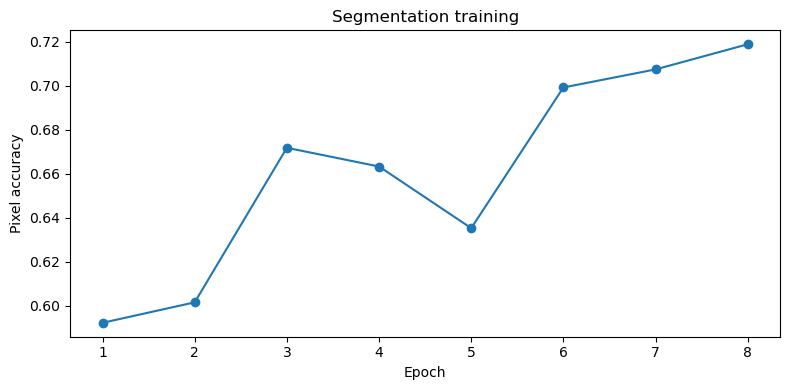

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Pixel accuracy')
plt.title('Segmentation training')
plt.tight_layout()
plt.show()

## Visualize Predictions

### Functions

In [22]:
def plot_triplet(image, mask, preds):
    """
    Plot an image, its true mask, and the predicted mask.

    Parameters:
        image (torch.Tensor): The image.
        mask (torch.Tensor): The true mask.
        preds (torch.Tensor): The predicted mask.

    Returns:
        None
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    titles = ['Image', 'True mask', 'Predicted mask']
    panels = [image.permute(1, 2, 0), mask, preds]
    for axis, title, panel in zip(axes, titles, panels):
        axis.imshow(panel, cmap=None if panel.dim() == 3 else 'viridis')
        axis.set_title(title)
        axis.axis('off')
    fig.tight_layout()
    plt.show()


def show_prediction(model, dataset, index=0):
    """
    Plot an image, its true mask, and the predicted mask.

    Parameters:
        model (nn.Module): Trained model.
        dataset (Dataset): Source of images and masks.
        index (int): Sample index.

    Returns:
        None
    """
    model.eval()
    image, mask = dataset[index]
    with torch.no_grad():
        preds = model(image.unsqueeze(0).to(DEVICE)).argmax(1)[0].cpu()
    plot_triplet(image, mask, preds)

### Run

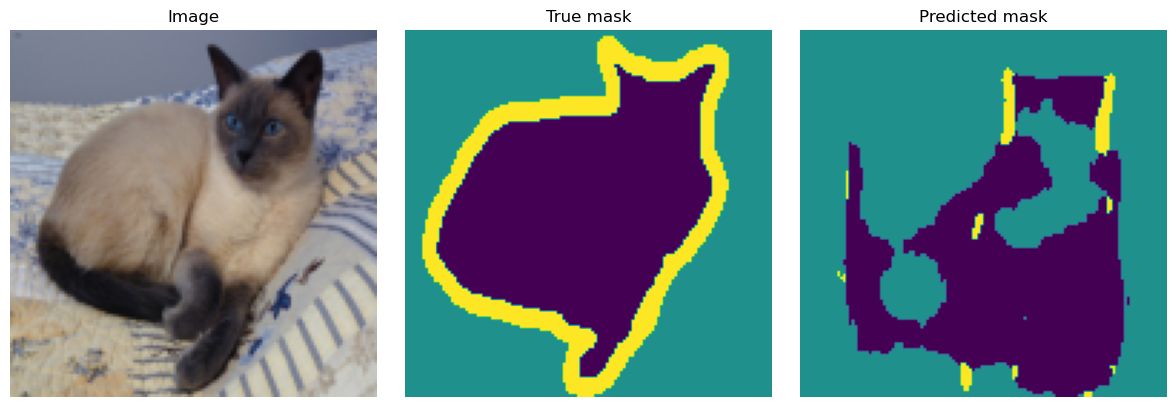

In [23]:
show_prediction(model, test_data, index=0)

## Save Model

In [24]:
torch.save(model.state_dict(), 'unet_oxford_pet.pt')
print('saved unet_oxford_pet.pt')

saved unet_oxford_pet.pt


## Load Model

In [25]:
loaded_model = UNet().to(DEVICE)
loaded_model.load_state_dict(torch.load('unet_oxford_pet.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded unet_oxford_pet.pt')

loaded unet_oxford_pet.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_56932/1089445556.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('unet

## Inference

### Function

In [26]:
def predict_mask(model, image):
    """
    Predict a segmentation mask for one image.

    Parameters:
        model (nn.Module): Trained model.
        image (torch.Tensor): A 3xHxW image tensor.

    Returns:
        torch.Tensor: Predicted mask.
    """
    model.eval()
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(DEVICE))
        return logits.argmax(1)[0].cpu()

### Run Inference

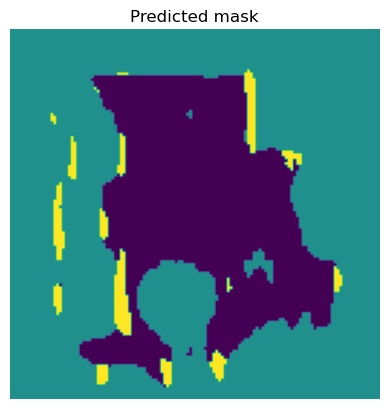

In [27]:
image, mask = test_data[1]
predicted = predict_mask(loaded_model, image)
plt.imshow(predicted, cmap='viridis')
plt.title('Predicted mask')
plt.axis('off')
plt.show()